In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objs as go
import os
%matplotlib inline

In [2]:
happiness_files = {
    2015: '2015.csv',
    2016: '2016.csv',
    2017: '2017.csv',
    2018: '2018.csv',
    2019: '2019.csv'
}
life_expectancy_file = 'Life Expectancy Data.csv'

In [3]:
column_mapper = {
    'Country or region': 'Country',
    'Happiness.Rank': 'Happiness_Rank',
    'Overall rank': 'Happiness_Rank',
    'Happiness Rank': 'Happiness_Rank',
    'Happiness.Score': 'Happiness_Score',
    'Score': 'Happiness_Score',
    'Happiness Score': 'Happiness_Score',
    'Economy (GDP per Capita)': 'GDP_per_Capita',
    'Economy..GDP.per.Capita.': 'GDP_per_Capita',
    'GDP per capita': 'GDP_per_Capita',
    'Health (Life Expectancy)': 'Health_Expectancy',
    'Health..Life.Expectancy.': 'Health_Expectancy',
    'Healthy life expectancy': 'Health_Expectancy'
}

In [4]:
df_list = []
for year, filepath in happiness_files.items():
    df_temp = pd.read_csv(filepath)
    df_temp = df_temp.rename(columns=column_mapper)
    df_temp['Year'] = year
    core_cols = ['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Health_Expectancy']
    valid_cols = [col for col in core_cols if col in df_temp.columns]
    df_list.append(df_temp[valid_cols])

df_hap_all = pd.concat(df_list, ignore_index=True)

In [5]:
df_life = pd.read_csv(life_expectancy_file)
df_life.columns = df_life.columns.str.strip()
df_life = df_life.rename(columns={
    'Life expectancy': 'Life_Expectancy_Years',
    'GDP': 'GDP_USD'
})

In [6]:
df_hap_all['Country'] = df_hap_all['Country'].astype(str).str.strip().str.strip('*')
df_life['Country'] = df_life['Country'].astype(str).str.strip()

In [7]:
df = pd.merge(df_hap_all, df_life, on=['Country', 'Year'], how='inner')
df = df.dropna(subset=['Happiness_Score', 'GDP_per_Capita', 'Life_Expectancy_Years'])
print("Data Overview (head):")
print(df[['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Life_Expectancy_Years']].head())
print("\nData Types:")
print(df[['Happiness_Score', 'GDP_per_Capita', 'Life_Expectancy_Years']].dtypes)

Data Overview (head):
       Country  Year  Happiness_Score  GDP_per_Capita  Life_Expectancy_Years
0  Switzerland  2015            7.587         1.39651                   83.4
1      Iceland  2015            7.561         1.30232                   82.7
2      Denmark  2015            7.527         1.32548                   86.0
3       Norway  2015            7.522         1.45900                   81.8
4       Canada  2015            7.427         1.32629                   82.2

Data Types:
Happiness_Score          float64
GDP_per_Capita           float64
Life_Expectancy_Years    float64
dtype: object



Descriptive Statistics Summary:
                            Mean    Median   Std Dev
Happiness_Score         5.384304   5.19400  1.159092
GDP_per_Capita          0.847639   0.91861  0.405702
Life_Expectancy_Years  72.074815  74.50000  8.384836


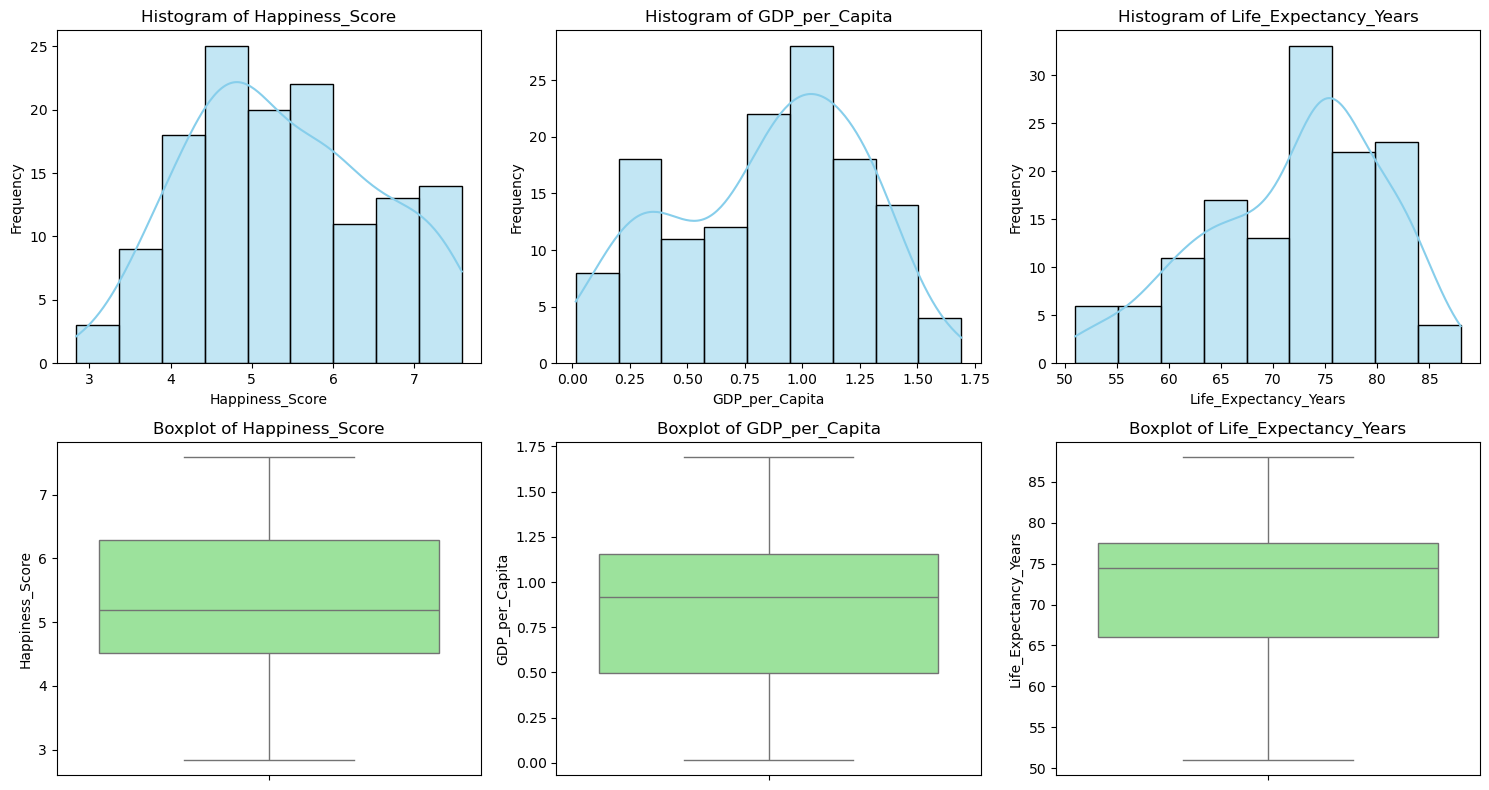

In [8]:
target_cols = ['Happiness_Score', 'GDP_per_Capita', 'Life_Expectancy_Years']

stats_summary = pd.DataFrame({
    'Mean': df[target_cols].mean(),
    'Median': df[target_cols].median(),
    'Std Dev': df[target_cols].std()
})
print("\nDescriptive Statistics Summary:")
print(stats_summary)

fig, axes = plt.subplots(nrows=2, ncols=len(target_cols), figsize=(15, 8))

for idx, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, idx], color='skyblue')
    axes[0, idx].set_title(f'Histogram of {col}')
    axes[0, idx].set_xlabel(col)
    axes[0, idx].set_ylabel('Frequency')
    
    sns.boxplot(y=df[col], ax=axes[1, idx], color='lightgreen')
    axes[1, idx].set_title(f'Boxplot of {col}')
    axes[1, idx].set_ylabel(col)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()


Pearson Correlation Matrix:
                       Happiness_Score  GDP_per_Capita  Life_Expectancy_Years
Happiness_Score               1.000000        0.798978               0.748720
GDP_per_Capita                0.798978        1.000000               0.819864
Life_Expectancy_Years         0.748720        0.819864               1.000000


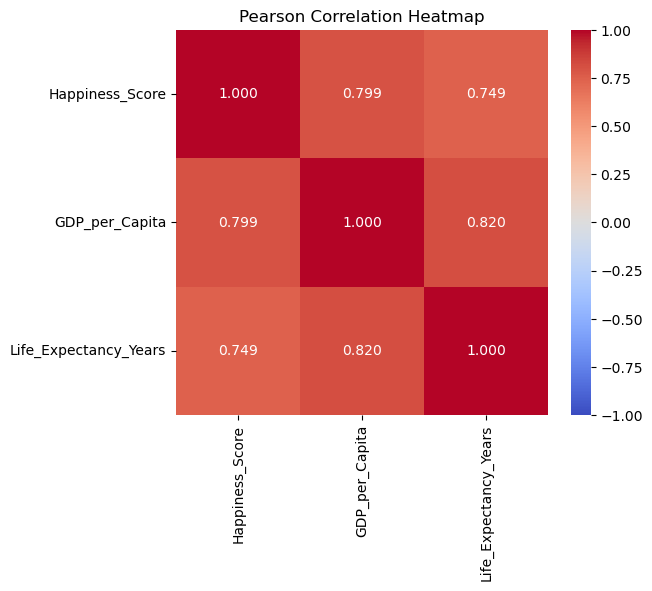


Model Comparison Table:
                       Model  Intercept  Coef (GDP)  Coef (Life Exp)  \
0               Single (GDP)   3.449414    2.282681              NaN   
1          Single (Life Exp)  -2.075481         NaN         0.103501   
2  Multiple (GDP + Life Exp)   1.169926    1.613412         0.039498   

   R-squared  Adj R-squared  
0   0.638365       0.635646  
1   0.560582       0.557278  
2   0.665128       0.660055  


In [9]:
corr_matrix = df[target_cols].corr(method='pearson')
print("\nPearson Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Pearson Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


model_gdp = smf.ols('Happiness_Score ~ GDP_per_Capita', data=df).fit()
model_life = smf.ols('Happiness_Score ~ Life_Expectancy_Years', data=df).fit()
model_multi = smf.ols('Happiness_Score ~ GDP_per_Capita + Life_Expectancy_Years', data=df).fit()

summary_table = pd.DataFrame({
    'Model': ['Single (GDP)', 'Single (Life Exp)', 'Multiple (GDP + Life Exp)'],
    'Intercept': [model_gdp.params['Intercept'], model_life.params['Intercept'], model_multi.params['Intercept']],
    'Coef (GDP)': [model_gdp.params.get('GDP_per_Capita', np.nan), np.nan, model_multi.params.get('GDP_per_Capita', np.nan)],
    'Coef (Life Exp)': [np.nan, model_life.params.get('Life_Expectancy_Years', np.nan), model_multi.params.get('Life_Expectancy_Years', np.nan)],
    'R-squared': [model_gdp.rsquared, model_life.rsquared, model_multi.rsquared],
    'Adj R-squared': [model_gdp.rsquared_adj, model_life.rsquared_adj, model_multi.rsquared_adj]
})

print("\nModel Comparison Table:")
print(summary_table)

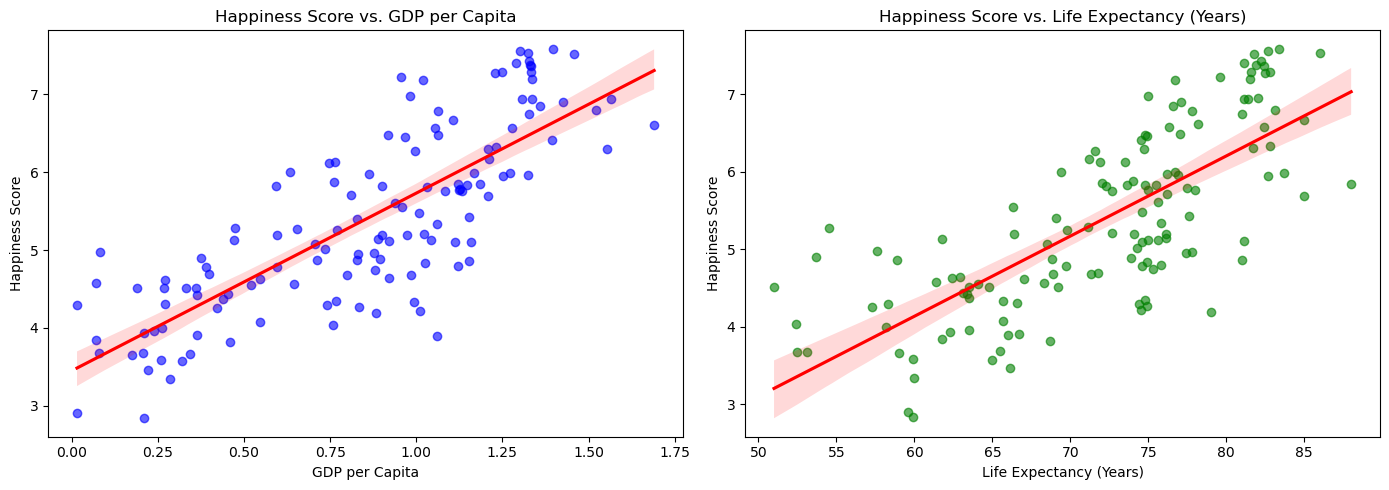

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='GDP_per_Capita', y='Happiness_Score', data=df, ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'blue'}, line_kws={'color':'red'})
axes[0].set_title('Happiness Score vs. GDP per Capita')
axes[0].set_xlabel('GDP per Capita')
axes[0].set_ylabel('Happiness Score')

sns.regplot(x='Life_Expectancy_Years', y='Happiness_Score', data=df, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'green'}, line_kws={'color':'red'})
axes[1].set_title('Happiness Score vs. Life Expectancy (Years)')
axes[1].set_xlabel('Life Expectancy (Years)')
axes[1].set_ylabel('Happiness Score')

plt.tight_layout()
plt.savefig('regression_plots.png', dpi=300, bbox_inches='tight')
plt.show()